# PhysioStress — Exploratory Data Analysis

This notebook inspects the raw physiological signals and the extracted feature table before any modeling happens.

In [1]:
import sys, os
sys.path.insert(0, "../src")
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import DATA_RAW_DIR, DATA_PROCESSED_DIR

sns.set_theme(style="whitegrid", context="notebook")

# This notebook can be run standalone: if the raw data hasn't been
# generated yet (e.g. a fresh checkout, before running any pipeline
# scripts from the command line), generate it now rather than erroring.
if not os.path.exists(os.path.join(DATA_RAW_DIR, "S2_synthetic.pkl")):
    print("Raw data not found in data/raw/ -- generating it now (a few seconds)...")
    from synthetic_data import generate_all_subjects
    generate_all_subjects(verbose=False)
    print("Done.")

with open(os.path.join(DATA_RAW_DIR, "S2_synthetic.pkl"), "rb") as f:
    subject = pickle.load(f)

fs = subject["chest_fs"]
label = subject["chest_label"]
print("Subject:", subject["subject_id"])
print("Total chest recording length:", len(label) / fs, "seconds")
print("Label codes present (0=transient, 1=baseline, 2=stress, 3=amusement):", sorted(set(label.tolist())))


Raw data not found in data/raw/ -- generating it now (a few seconds)...
Done.
Subject: S2
Total chest recording length: 1110.0 seconds
Label codes present (0=transient, 1=baseline, 2=stress, 3=amusement): [0, 1, 2, 3]


## Raw signal preview

A look at 60 seconds of raw ECG, EDA, respiration, and accelerometer-magnitude signal from each condition, for one subject. Note the qualitative differences: heart rate is visibly faster in stress, EDA sits at a higher level, respiration is faster/shallower, and movement is much less "flat" than at baseline.

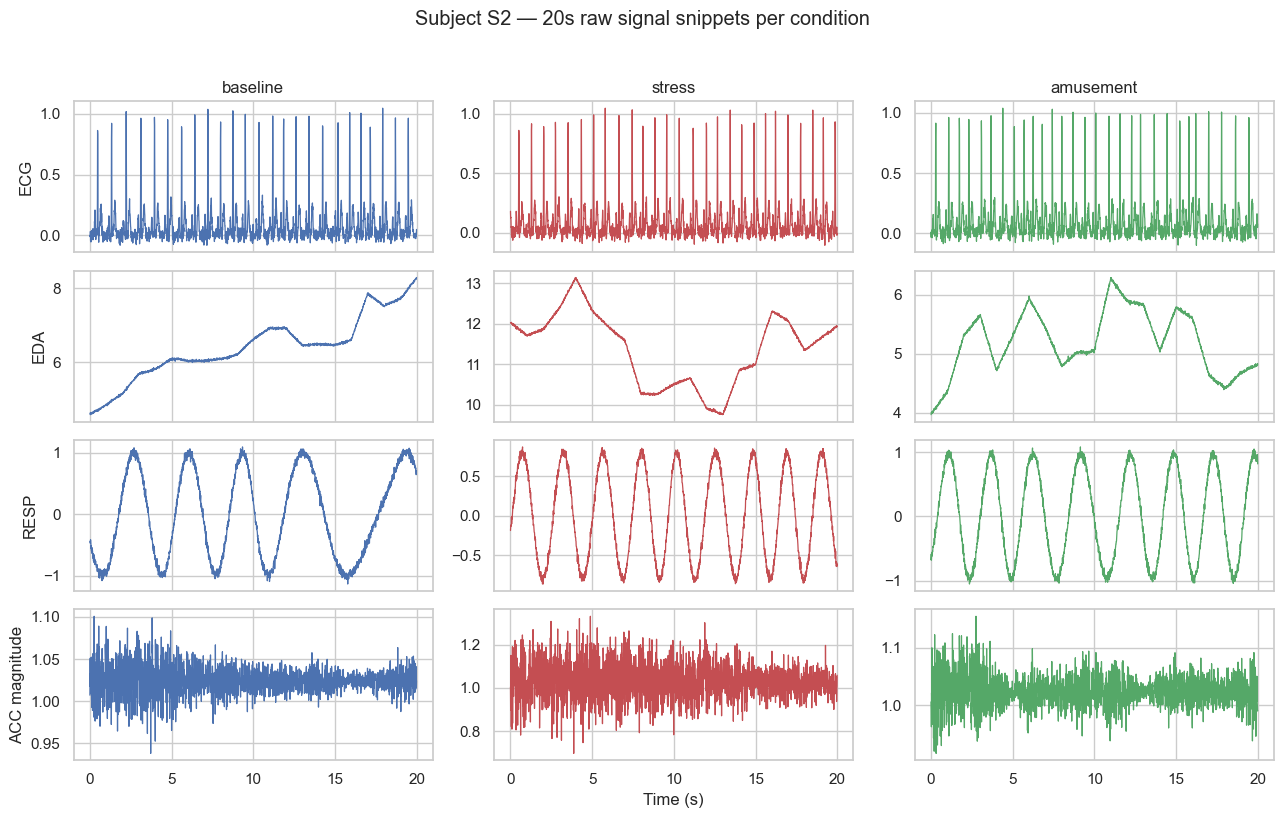

In [2]:
def segment_window(sig, label_arr, code, fs, seconds=60):
    idx = np.where(label_arr == code)[0]
    start = idx[len(idx)//3]  # a representative chunk, not right at the edge of the segment
    return sig[start:start + seconds*fs]

conditions = [("baseline", 1), ("stress", 2), ("amusement", 3)]
signals_to_plot = [("ECG", subject["chest"]["ECG"]), ("EDA", subject["chest"]["EDA"]),
                    ("RESP", subject["chest"]["RESP"])]
acc_mag = np.sqrt(subject["chest"]["ACC_x"]**2 + subject["chest"]["ACC_y"]**2 + subject["chest"]["ACC_z"]**2)
signals_to_plot.append(("ACC magnitude", acc_mag))

fig, axes = plt.subplots(len(signals_to_plot), 3, figsize=(13, 8), sharex=True)
colors = {"baseline": "#4C72B0", "stress": "#C44E52", "amusement": "#55A868"}
for col, (cond_name, code) in enumerate(conditions):
    for row, (sig_name, sig) in enumerate(signals_to_plot):
        seg = segment_window(sig, label, code, fs, seconds=20)
        t = np.arange(len(seg)) / fs
        axes[row, col].plot(t, seg, color=colors[cond_name], linewidth=0.9)
        if row == 0:
            axes[row, col].set_title(cond_name)
        if col == 0:
            axes[row, col].set_ylabel(sig_name)
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Subject S2 — 20s raw signal snippets per condition", y=1.02)
plt.tight_layout()
plt.show()


## Windowed & feature-extracted dataset

After preprocessing (filtering, segmentation into 60s/50%-overlap windows) and feature extraction, every window becomes one row of 55 physiological features + subject ID + label.

In [3]:
if not os.path.exists(os.path.join(DATA_PROCESSED_DIR, "features.csv")):
    print("Feature table not found -- extracting features now (a few seconds)...")
    from preprocessing import build_all_windows
    from feature_extraction import build_feature_dataframe
    from utils import SUBJECT_IDS
    records = build_all_windows(SUBJECT_IDS, verbose=False)
    feat_df = build_feature_dataframe(records, verbose=False)
    feat_df.to_csv(os.path.join(DATA_PROCESSED_DIR, "features.csv"), index=False)
    print("Done.")

df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "features.csv"))
print("Shape:", df.shape)
print("\nSubjects:", df['subject_id'].nunique())
print("\nClass distribution:")
print(df['label'].value_counts())
df.head()


Shape: (495, 57)

Subjects: 15

Class distribution:
label
baseline     225
stress       165
amusement    105
Name: count, dtype: int64


,subject_id,label,eda_chest_mean,eda_chest_std,eda_chest_slope,eda_chest_tonic_mean,eda_chest_tonic_slope,eda_chest_phasic_std,eda_chest_scr_count,eda_chest_scr_amp_mean,...,temp_wrist_slope,temp_wrist_std,acc_chest_mag_mean,acc_chest_mag_std,acc_chest_energy,acc_chest_activity_counts,acc_wrist_mag_mean,acc_wrist_mag_std,acc_wrist_energy,acc_wrist_activity_counts
0,S2,baseline,7.929437,1.326695,-0.057467,7.537284,-0.048056,1.212408,11.0,0.669514,...,0.000559,0.014297,1.024329,0.022668,1.049764,178.0,0.995918,0.020904,0.992289,57.0
1,S2,baseline,7.289279,0.978930,-0.004649,6.984450,-0.001134,0.932490,13.0,0.647933,...,0.000384,0.013957,1.024339,0.022984,1.049799,178.0,0.995937,0.025775,0.992554,56.0
2,S2,baseline,7.381071,0.981034,-0.017431,7.066382,-0.016624,0.939639,12.0,0.796224,...,0.000614,0.014225,1.024676,0.027523,1.050718,188.0,0.996874,0.028566,0.994574,59.0
3,S2,baseline,5.966396,1.620426,-0.068660,5.699687,-0.064556,0.885010,11.0,0.846898,...,-0.000553,0.011720,1.024597,0.023360,1.050345,178.0,0.997109,0.029015,0.995068,62.0
4,S2,baseline,5.270092,1.223978,0.043851,4.972500,0.041457,1.015251,9.0,0.836048,...,-0.000358,0.009034,1.024019,0.018213,1.048947,168.0,0.995504,0.025368,0.991672,57.0


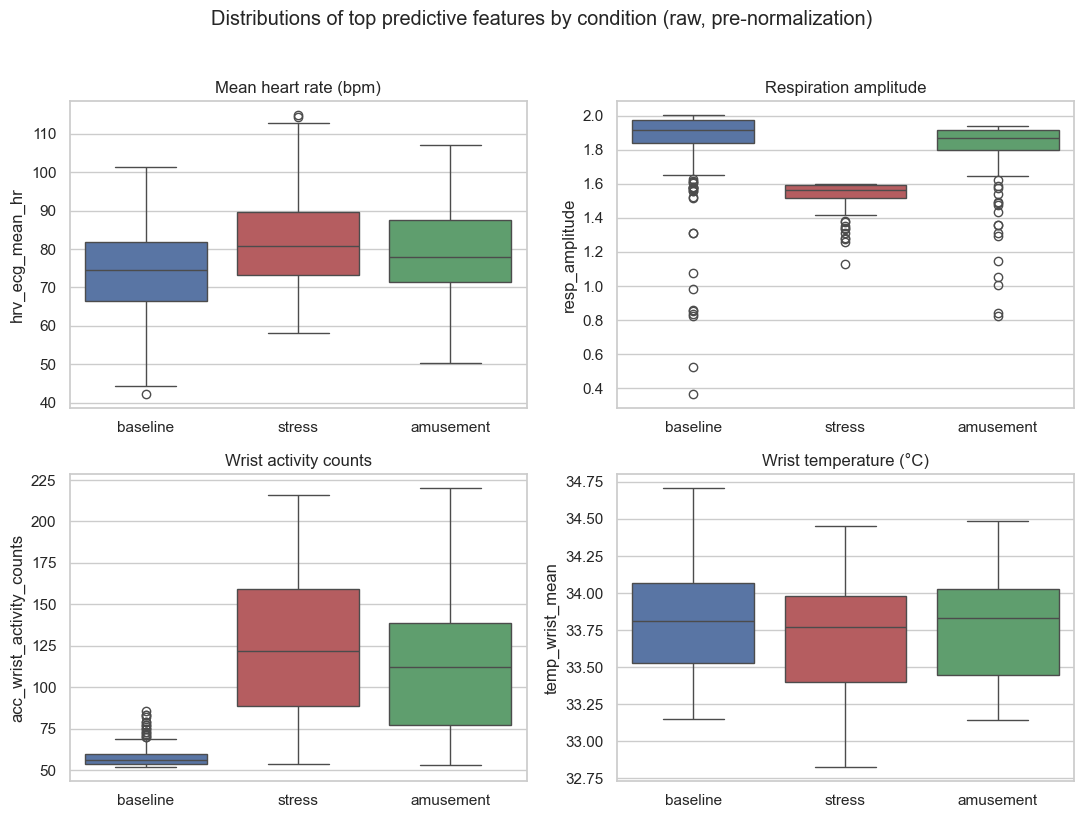

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
feature_panels = [
    ("hrv_ecg_mean_hr", "Mean heart rate (bpm)"),
    ("resp_amplitude", "Respiration amplitude"),
    ("acc_wrist_activity_counts", "Wrist activity counts"),
    ("temp_wrist_mean", "Wrist temperature (°C)"),
]
order = ["baseline", "stress", "amusement"]
palette = {"baseline": "#4C72B0", "stress": "#C44E52", "amusement": "#55A868"}
for ax, (feat, title) in zip(axes.ravel(), feature_panels):
    sns.boxplot(data=df, x="label", y=feat, order=order, hue="label", palette=palette, legend=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
fig.suptitle("Distributions of top predictive features by condition (raw, pre-normalization)", y=1.02)
plt.tight_layout()
plt.show()


Even before per-subject baseline normalization or any modeling, several features already show a visible shift across conditions in the expected physiological direction — heart rate and movement rise under stress/amusement relative to baseline, respiration amplitude drops under stress, and wrist temperature drifts down under stress. Modeling and formal LOSO evaluation are covered in `02_results_walkthrough.ipynb`.